# Hands-On Part B
This notebook covers the interpretation of a pre-trained CNN image classifier (VGG16) by generating and comparing Saliency Maps and Grad-CAM visualizations.

## 1. Setup and Imports
Import required libraries, including TensorFlow/Keras applications for the pre-trained model.

In [4]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 4.3 MB/s  0:00:08m0:00:0100:01


In [1]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
import cv2 # For image resizing and color mapping

# Keras Applications imports
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.imagenet_utils import decode_predictions

# Set seed for reproducibility (optional)
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2.Load Model and Data (VGG16 on ImageNet)
Load the VGG16 model and preprocess a sample image.

In [2]:
## --- Configuration --- ##
# VGG16 standard input size
TARGET_SIZE = (224, 224) 
# Assumes you have downloaded a test image (e.g., a dog) and saved it here
TEST_IMAGE_PATH = 'labrador.jpg' 

# The name of the last convolutional layer in VGG16 for Grad-CAM
LAST_CONV_LAYER_NAME = 'block5_conv3' 

In [3]:
## --- Load Model --- ##
# Load VGG16 pre-trained on ImageNet (1000 classes)
model = VGG16(weights='imagenet') 
print("VGG16 Model loaded successfully with ImageNet weights.")
model.summary() # Uncomment to see the layer names

VGG16 Model loaded successfully with ImageNet weights.


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# --- Updated Image Preprocessing Function for VGG16 ---
def preprocess_image(img_path, target_size):
    # Load the image
    img = image.load_img(img_path, target_size=target_size)
    
    # Convert to numpy array and add a batch dimension (1, 224, 224, 3)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    
    # Apply VGG16's specific preprocessing (converts RGB to BGR and zero-centers channels)
    img_tensor = preprocess_input(img_array) 
    
    # The original PIL image is used for visualization
    return img_tensor, img

In [5]:
# Load the test image
try:
    test_img_tensor, original_img = preprocess_image(TEST_IMAGE_PATH, TARGET_SIZE)

    # Make a prediction
    predictions = model.predict(test_img_tensor)
    predicted_class_idx = np.argmax(predictions[0])

    # Decode and display the prediction
    decoded_predictions = decode_predictions(predictions, top=1)[0][0]
    predicted_class_name = decoded_predictions[1]
    
    print(f"\nTest image loaded. Shape: {test_img_tensor.shape}")
    print(f"Prediction: {predicted_class_name} (Index: {predicted_class_idx})")
    
except FileNotFoundError:
    print(f"\nERROR: Please ensure the image file '{TEST_IMAGE_PATH}' is in the current directory.")
    predicted_class_idx = None # Stop further execution if file not found

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step

Test image loaded. Shape: (1, 224, 224, 3)
Prediction: Labrador_retriever (Index: 208)


## 3. Simple Gradient Saliency Map
This method computes the gradient of the predicted class score with respect to the input pixels, showing pixel-level sensitivity.

In [6]:
# Function to compute Vanilla Saliency
def compute_vanilla_saliency(model, img_tensor, class_idx):
    input_tensor = tf.convert_to_tensor(img_tensor, dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(input_tensor)
        # Get the prediction score for the target class
        predictions = model(input_tensor)
        score = predictions[0, class_idx]

    # Compute the gradient of the score w.r.t the input image
    gradients = tape.gradient(score, input_tensor)
    
    # Take the absolute value and maximize across color channels for visualization
    saliency = tf.abs(gradients[0])
    saliency = tf.reduce_max(saliency, axis=-1)

    # Normalize for better visualization (0 to 1)
    saliency = saliency / tf.reduce_max(saliency)
    
    return saliency.numpy()

In [7]:
# Function to display the result
def display_saliency(original_img, saliency_map, title):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    axes[0].imshow(original_img)
    axes[0].set_title(f"Original Image\n(Prediction: {predicted_class_name})")
    axes[0].axis('off')

    axes[1].imshow(original_img, alpha=0.5)
    # Overlay the saliency map
    axes[1].imshow(saliency_map, cmap='hot', alpha=0.7, interpolation='bilinear')
    axes[1].set_title(title)
    axes[1].axis('off')
    
    plt.show()

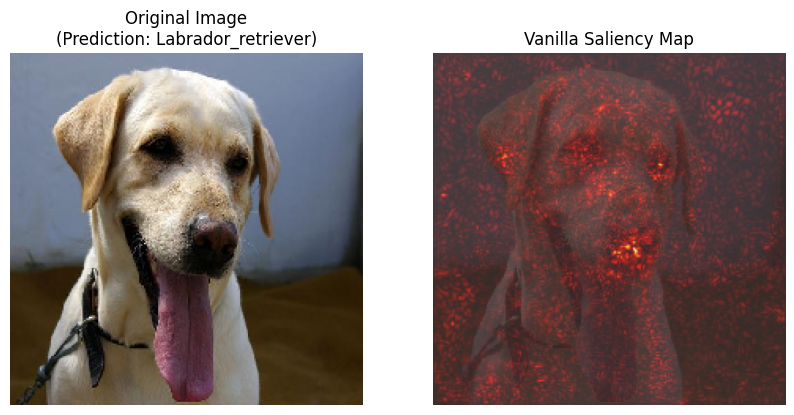

In [8]:
if predicted_class_idx is not None:
    # Compute and display the vanilla saliency map
    saliency_map_vanilla = compute_vanilla_saliency(model, test_img_tensor, predicted_class_idx)
    display_saliency(original_img, saliency_map_vanilla, "Vanilla Saliency Map")

## 4. Grad-CAM (Gradient-weighted Class Activation Mapping)
Grad-CAM uses the gradient of the final prediction with respect to the last convolutional layer's features to generate a coarse localization map.

In [9]:
# Function to generate the Grad-CAM heatmap
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index):
    # 1. Create a model mapping input to last conv layer output and final output
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        # Get the score for the target class
        class_channel = preds[:, pred_index]

    # 2. Compute the gradients of the target class score w.r.t the last conv layer outputs
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # 3. Compute the mean intensity of the gradient for each feature map (Global Average Pooling)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 4. Multiply each channel's activation map by its importance (pooled_grads)
    last_conv_layer_output = last_conv_layer_output[0] # remove batch dim
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 5. Normalize the heatmap (ReLU and scaling)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    
    return heatmap.numpy()

In [10]:
# Function to overlay Grad-CAM onto the original image
def display_gradcam(img, heatmap, alpha=0.4):
    # Rescale heatmap to full size (224x224)
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.resize(heatmap, TARGET_SIZE)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    
    # Convert original PIL image to array (0-255 scale)
    img_array_255 = np.array(img).astype('float32')
    
    # Blend the heatmap and the image
    # Note: cv2 uses BGR, but we'll use a simplified weighted blend for consistency
    superimposed_img = heatmap * alpha + img_array_255 * (1 - alpha)
    
    # Normalize and display
    superimposed_img = np.clip(superimposed_img, 0, 255).astype('uint8')
    final_img = Image.fromarray(superimposed_img)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(final_img)
    plt.title(f"Grad-CAM Visualization\n(Layer: {LAST_CONV_LAYER_NAME})")
    plt.axis('off')
    plt.show()

/Users/jasonlau/.pyenv/versions/3.11.11/envs/deeplearn/lib/python3.11/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


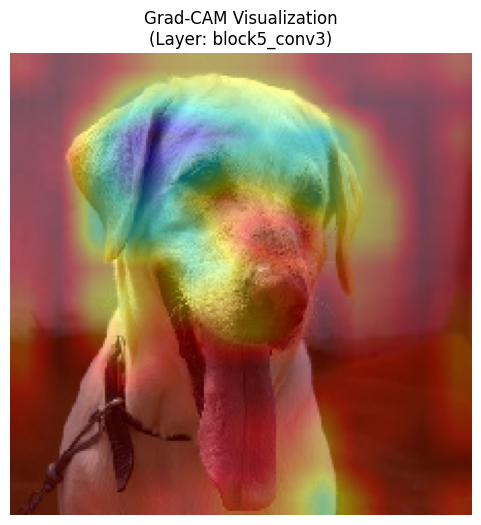

In [11]:
if predicted_class_idx is not None:
    # Generate the Grad-CAM heatmap
    heatmap_gradcam = make_gradcam_heatmap(
        test_img_tensor, 
        model, 
        LAST_CONV_LAYER_NAME, 
        pred_index=predicted_class_idx
    )

    # Visualize the Grad-CAM map
    display_gradcam(original_img, heatmap_gradcam)

## 5. Comparison and Discussion

Comparison: Grad-CAM vs. Simple Gradient
Feature|Simple Gradient (Vanilla Saliency)|Grad-CAM (block5_conv3)
-------|----------------------------------|--------
Localization|Pixel-level (Very precise, often noisy)|Region-level (Coarse, highlights object)
Clarity|Highlights high-frequency data (e.g., edges, textures).|Provides a smooth, clear heatmap over the object.
Interpretability|Good for finding minute details the model relies on (often texture/noise).|Excellent for determining where the model is looking (the object itself).

Discussion of Findings:
1. Vanilla Saliency: For the Labrador image, the saliency map will likely show high activation along the sharp outlines of the dog, around the eyes, or on textured areas like fur. This confirms the model uses fine texture and edge features for classification.
2. Grad-CAM: The Grad-CAM heatmap should show a strong, continuous heat spot covering the dog's head and body. This demonstrates that the high-level features learned in the final convolutional block (block5_conv3) successfully localize the object responsible for the final 'Labrador' classification.

What Features Did the Model Actually Learn?
Based on VGG16's successful classification and visualization:
- Low-Level Features (Vanilla Saliency): The initial layers (and thus the Vanilla Saliency) learned to extract fundamental features like edges, corners, and color gradients (e.g., the boundary between the dog and the background).
- High-Level Features (Grad-CAM): The final convolutional block learned to aggregate these low-level features into recognizable semantic parts (e.g., the shape of the dog's head, the texture of its coat). The model is classifying the image based on the spatial presence of the entire "dog" object, not just peripheral details.